# Training History Visualization

This notebook provides visualizations of the training history for your deep learning models (LSTM, 1D-CNN, Transformer, CNN-LSTM, TCN) based on the logs extracted from `FYP.ipynb`.

**Note:** This allows you to view the accuracy and loss curves without re-running the time-consuming training process.

In [1]:
import json
import matplotlib.pyplot as plt
import os

# Path to the extracted data
data_path = r"c:/Users/user/.gemini/antigravity/brain/6ee028fe-45c2-4e6c-b7ab-5d44b648eed5/training_data.json"

def plot_model_history(model_name, data):
    epochs = range(1, len(data['accuracy']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, data['accuracy'], 'b', label='Training accuracy')
    if data['val_accuracy']:
        plt.plot(epochs, data['val_accuracy'], 'r', label='Validation accuracy')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, data['loss'], 'b', label='Training loss')
    if data['val_loss']:
        plt.plot(epochs, data['val_loss'], 'r', label='Validation loss')
    plt.title(f'{model_name} Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()

Loaded training data for: ['LSTM', '1D-CNN', 'Transformer', 'CNN-LSTM', 'TCN']


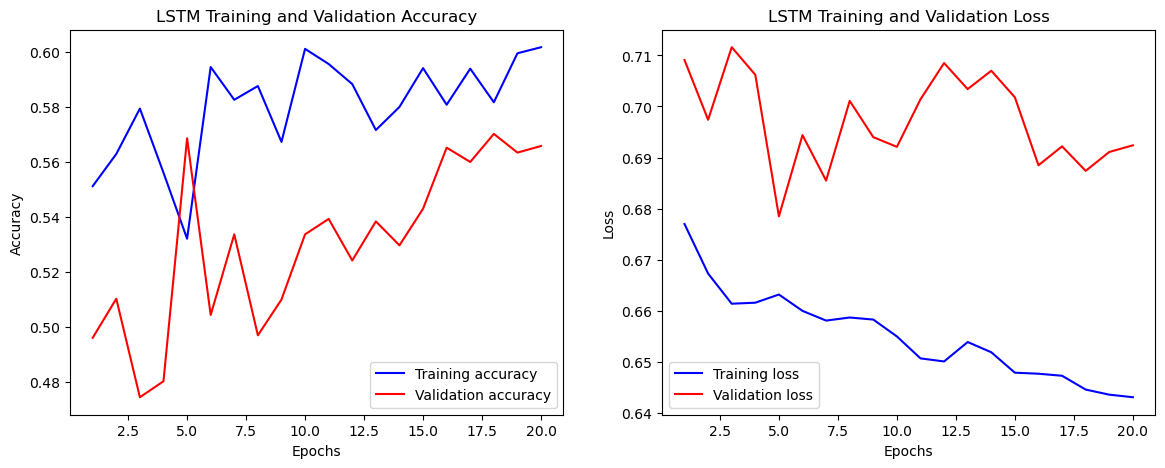

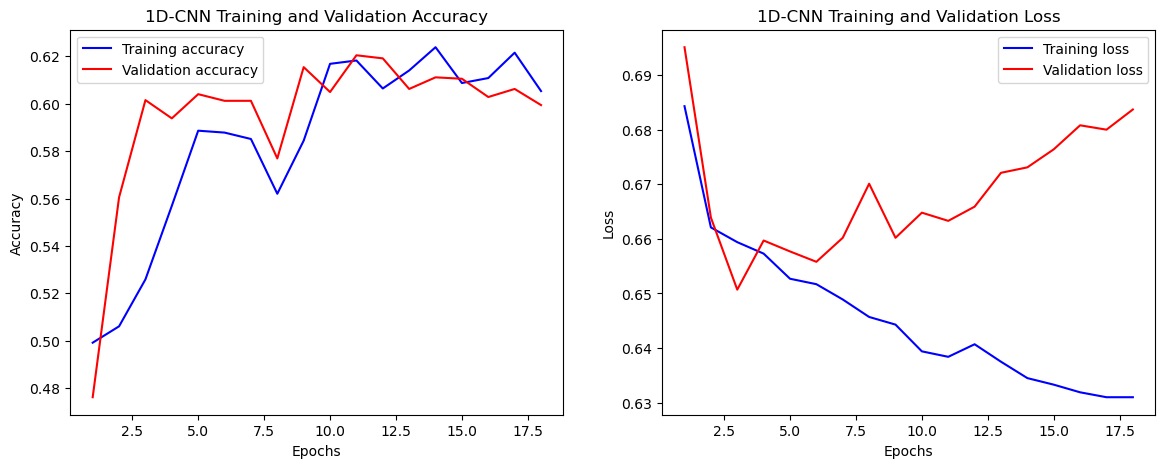

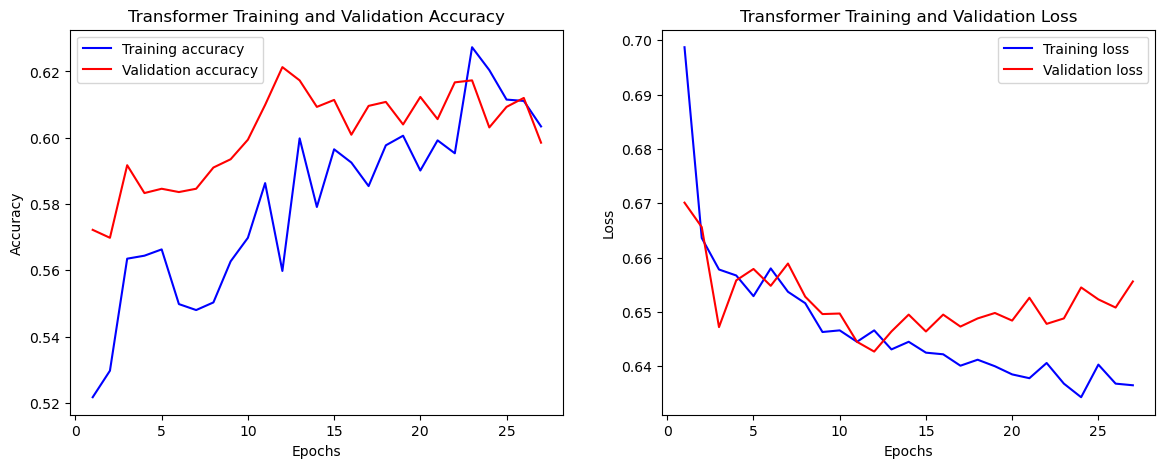

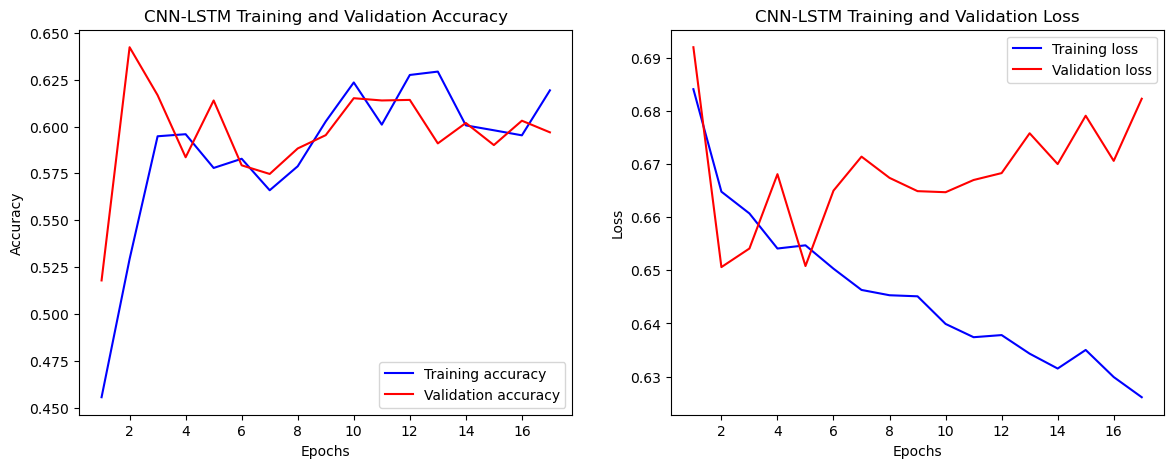

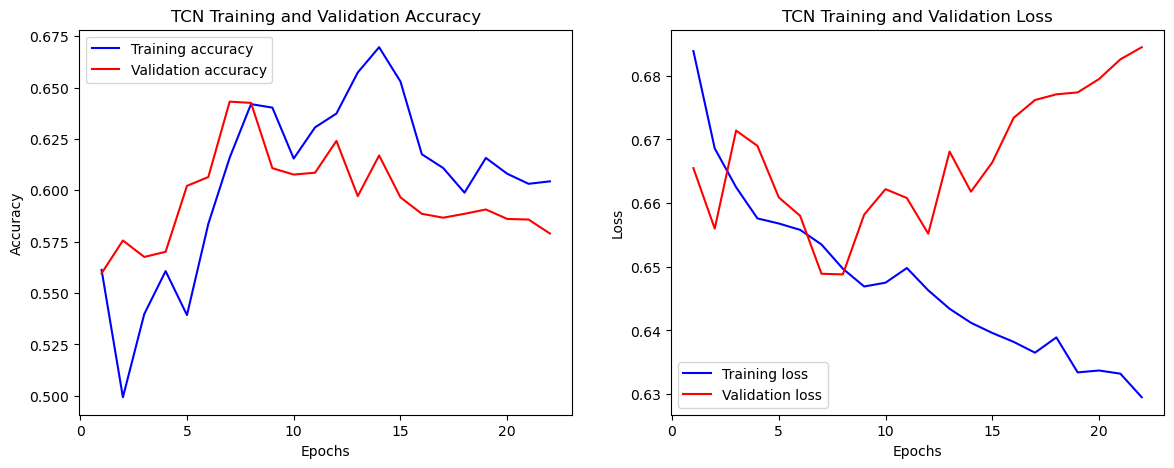

In [2]:
# Load Data
if os.path.exists(data_path):
    with open(data_path, 'r') as f:
        all_data = json.load(f)
    
    print(f"Loaded training data for: {list(all_data.keys())}")
    
    # Generate Plots
    for model_name, history in all_data.items():
        plot_model_history(model_name, history)
else:
    print(f"Error: Data file not found at {data_path}. Please ensure extract_and_plot_logs.py has run successfully.")

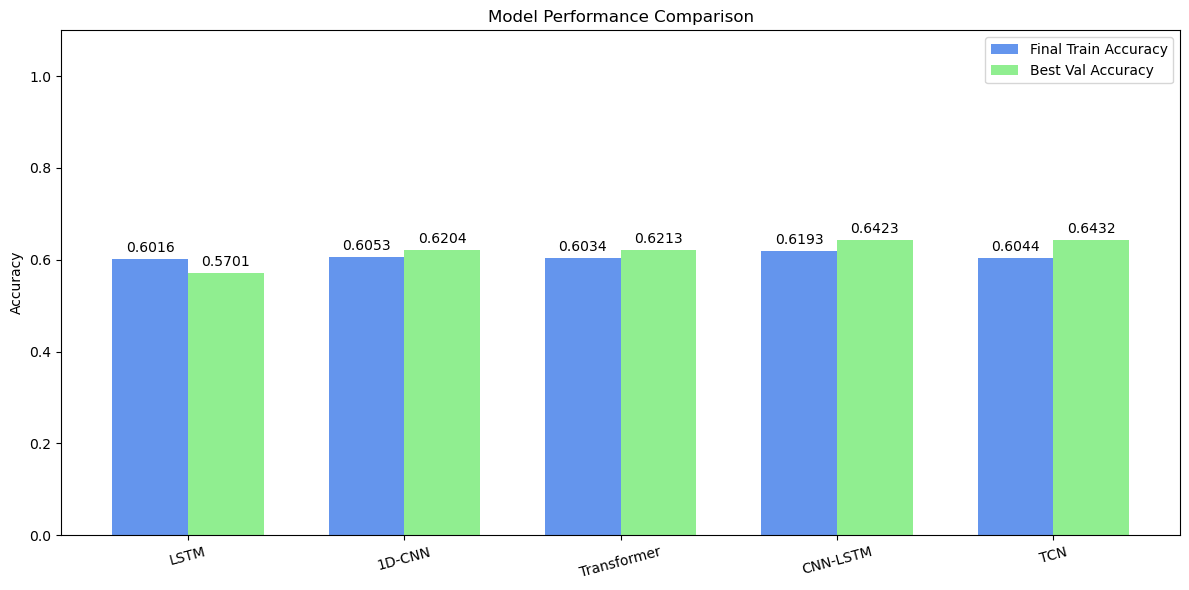

In [3]:
# --- Model Comparison Bar Chart ---
import numpy as np

if 'all_data' in locals() and all_data:
    models = list(all_data.keys())
    train_accs = []
    val_accs = []

    for model in models:
        history = all_data[model]
        # Get final training accuracy (last epoch)
        final_train_acc = history['accuracy'][-1] if history['accuracy'] else 0
        train_accs.append(final_train_acc)
        
        # Get best validation accuracy (max)
        best_val_acc = max(history['val_accuracy']) if history['val_accuracy'] else 0
        val_accs.append(best_val_acc)

    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(12, 6))
    ax = plt.subplot(111)
    rects1 = ax.bar(x - width/2, train_accs, width, label='Final Train Accuracy', color='#6495ED')
    rects2 = ax.bar(x + width/2, val_accs, width, label='Best Val Accuracy', color='#90EE90')

    ax.set_ylabel('Accuracy')
    ax.set_title('Model Performance Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15)
    ax.legend()
    ax.set_ylim(0, 1.1) # Add some headroom for labels

    # Add labels atop bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords='offset points',
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()

# Final Test Model Comparison

C:\Users\user\AppData\Local\Temp\ipykernel_27748\3824765487.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Test Accuracy', data=df_acc, palette='viridis')


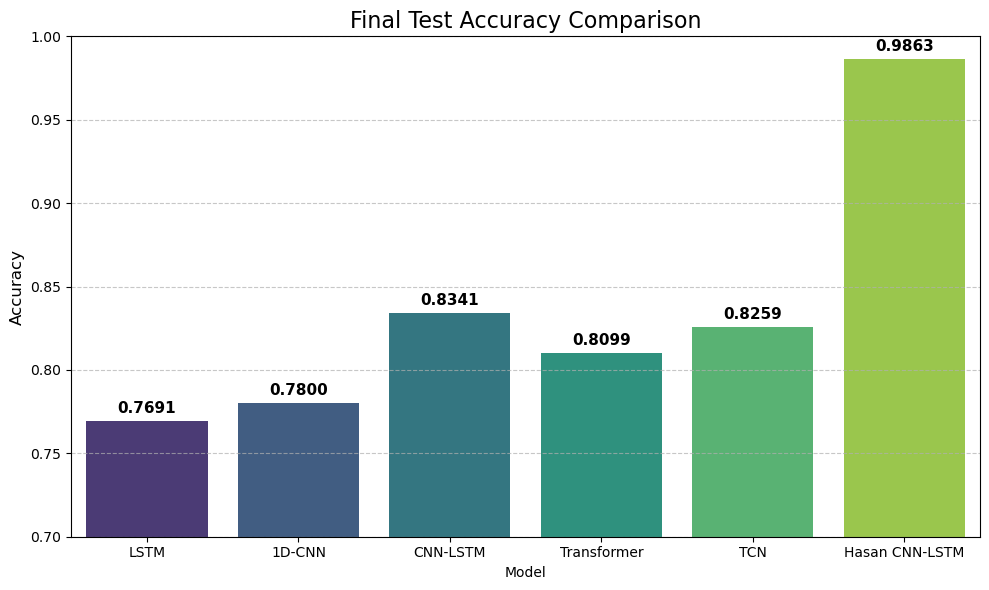

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data provided by user
accuracy_data = {
    'Model': ['LSTM', '1D-CNN', 'CNN-LSTM', 'Transformer', 'TCN', 'Hasan CNN-LSTM'],
    'Test Accuracy': [0.7691, 0.7800, 0.8341, 0.8099, 0.8259, 0.9863]
}

df_acc = pd.DataFrame(accuracy_data)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Test Accuracy', data=df_acc, palette='viridis')

plt.title('Final Test Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.7, 1.0)  # Zoom in to see differences better, assuming range is high
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value annotations on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Target Variable Distribution Analysis
This section visualizes the distribution of the target variable ('Heavy Rain') and the underlying precipitation data.

Loaded 'Cleaned_Encoded_Malaysia_Weather_Data.csv' successfully.

Target Variable Distribution Analysis
Total Samples: 20252

Class Counts:
0 (Not Heavy): 17843 (88.10%)
1 (Heavy):     2409 (11.90%)


C:\Users\user\AppData\Local\Temp\ipykernel_8420\2535496471.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target_binary', ax=axes[1], palette='viridis')


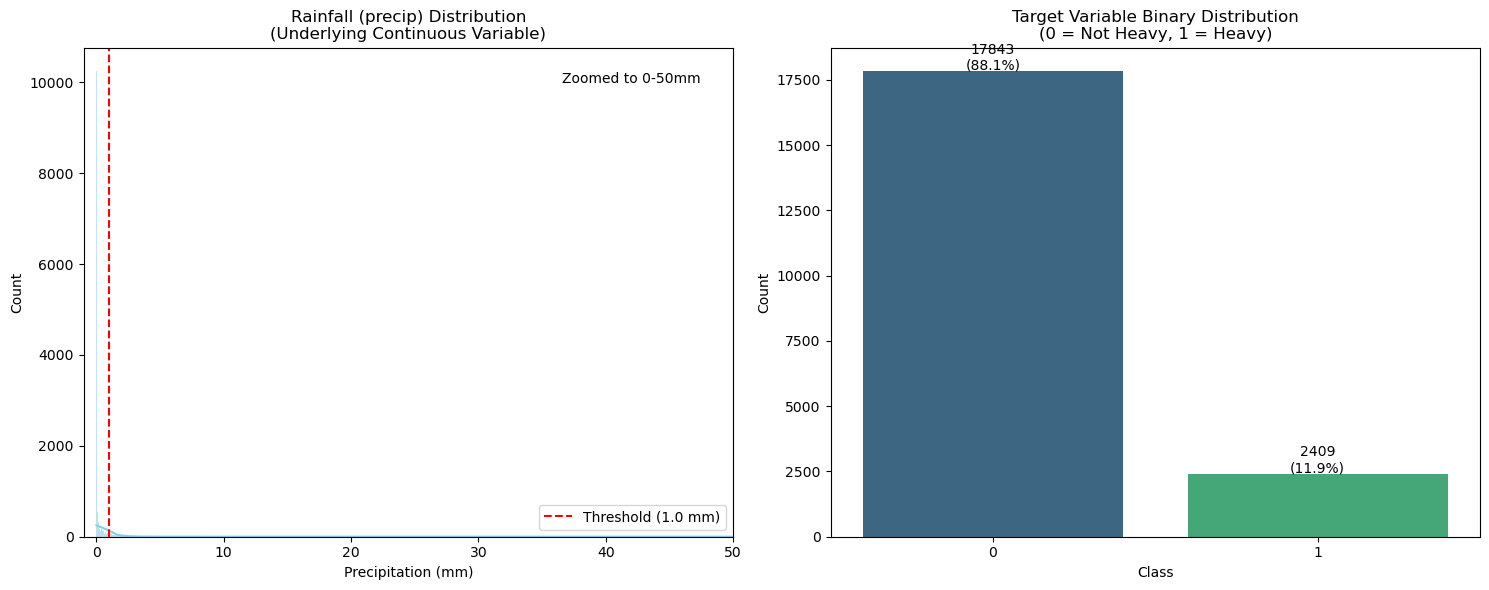

In [1]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load data - Assuming standard path, adjust if needed
try:
    df = pd.read_csv('Cleaned_Encoded_Malaysia_Weather_Data.csv')
    print("Loaded 'Cleaned_Encoded_Malaysia_Weather_Data.csv' successfully.")
except FileNotFoundError:
    # Fallback to absolute path just in case
    df = pd.read_csv(r'c:/Users/user/Documents/MMU/Y3/FYP/FYP_Code/Cleaned_Encoded_Malaysia_Weather_Data.csv')
    print("Loaded absolute path CSV.")

# Create target variable based on notebook logic
# 0 = Not Heavy (<= 1.0 mm), 1 = Heavy (> 1.0 mm)
if 'precip' in df.columns:
    df['target_binary'] = (df['precip'] > 1.0).astype(int)
    
    # Calculate counts
    class_counts = df['target_binary'].value_counts().sort_index()
    total = len(df)
    percentage = class_counts / total * 100

    print("\nTarget Variable Distribution Analysis")
    print("=====================================")
    print(f"Total Samples: {total}")
    print("\nClass Counts:")
    print(f"0 (Not Heavy): {class_counts.get(0, 0)} ({percentage.get(0, 0):.2f}%)")
    print(f"1 (Heavy):     {class_counts.get(1, 0)} ({percentage.get(1, 0):.2f}%)")

    # Setup plots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Continuous Distribution (Histogram + KDE) - Matching user Example style
    # Filter out extreme outliers for better visualization if needed, but plotting all first.
    # Zoom in to 0-50mm for readability as max can be huge
    sns.histplot(data=df, x='precip', kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Rainfall (precip) Distribution\n(Underlying Continuous Variable)')
    axes[0].set_xlabel('Precipitation (mm)')
    axes[0].axvline(x=1.0, color='r', linestyle='--', label='Threshold (1.0 mm)')
    
    # Zoom x-axis if max precip is very large (e.g. > 100) to see the distribution near 0
    if df['precip'].max() > 50:
        axes[0].set_xlim(-1, 50) 
        axes[0].text(0.95, 0.95, 'Zoomed to 0-50mm', transform=axes[0].transAxes, ha='right', va='top')
    
    axes[0].legend()

    # Plot 2: Target Binary Distribution (Count Plot) - Actual Model Target
    sns.countplot(data=df, x='target_binary', ax=axes[1], palette='viridis')
    axes[1].set_title('Target Variable Binary Distribution\n(0 = Not Heavy, 1 = Heavy)')
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Count')

    # Add count labels
    for i, count in enumerate(class_counts):
        axes[1].text(i, count + 50, f'{count}\n({percentage[i]:.1f}%)', ha='center')

    plt.tight_layout()
    plt.show()
else:
    print("Error: 'precip' column not found in dataset.")
